## Part B Q1: Dataset and Exploratory Data Analysis

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

from clean_review import clean_review

DATA_DIR = Path("../data")
RAW_FILE = DATA_DIR / "yelp_review_full_raw_30k.csv"
CLEAN_FILE = DATA_DIR / "yelp_clean.csv"
OUT_DIR = Path("eda_outputs")
OUT_DIR.mkdir(exist_ok=True)

### 1. Data Source

In [2]:
raw = pd.read_csv(RAW_FILE)

print("Rows            :", len(raw))
print("Columns         :", list(raw.columns))
print("Missing values  :", raw.isnull().sum().sum())
print("Reviews per star:")
print(raw["rating"].value_counts().sort_index().to_string())

balanced = raw["rating"].value_counts().nunique() == 1
print("\nExactly balanced across the 5 star ratings:", balanced)

Rows            : 30000
Columns         : ['review', 'rating']
Missing values  : 0
Reviews per star:
rating
1    6000
2    6000
3    6000
4    6000
5    6000

Exactly balanced across the 5 star ratings: True


### 2. Load Data and Derive the Target

In [3]:
def to_sentiment(rating):
    return np.where(rating <= 2, "negative", np.where(rating == 3, "neutral", "positive"))


df = raw.copy()
df["sentiment"] = to_sentiment(df["rating"])

print("Sample records:")
for i in range(3):
    row = df.iloc[i]
    review = " ".join(str(row["review"]).replace(r"\n", " ").split())
    print(f"\nRecord {i + 1}")
    print(f"Rating: {row['rating']} | Sentiment: {row['sentiment']}")
    print("Review:")
    print(review)

Sample records:

Record 1
Rating: 1 | Sentiment: negative
Review:
HORRIBLE PHARMACY!!! If you are in a hurry or in no mood to wait for your prescription, DO NOT COME HERE! Told me 15 mins and it's been 40. Still counting...

Record 2
Rating: 4 | Sentiment: positive
Review:
Great patio and friendly staff. I recommmd the Ahi Tuna taco platter.

Record 3
Rating: 4 | Sentiment: positive
Review:
This restaurant was splendid across the entire spectrum. As a trendy place to enjoy lunch on any day, the service was superb and the meal was even better. I had the \"buffalo chicken macaroni and cheese\" and it was fantastic! You could really sit and read the menu for hours as each item sounds just absolutely wonderful. I can't wait to return!


### 3. Data Quality

In [4]:
print("Missing values")
print(df[["review", "rating"]].isnull().sum().to_string())

print("\nExact duplicate review texts:", df.duplicated(subset=["review"]).sum())

Missing values
review    0
rating    0

Exact duplicate review texts: 0


### 4. Data Preparation and Cleaning

In [5]:
df = df.dropna(subset=["review", "rating"]).copy()
df["clean_text"] = df["review"].apply(clean_review)

before = len(df)
df = df[df["clean_text"].str.strip() != ""].copy()

print("Rows before cleaning:", before)
print("Rows after cleaning :", len(df), " (empty rows dropped:", before - len(df), ")")

Rows before cleaning: 30000
Rows after cleaning : 29998  (empty rows dropped: 2 )


In [6]:
# What the cleaning actually does to a review.
for i in range(3):
    before_text = " ".join(str(df["review"].iloc[i]).replace(r"\n", " ").split())
    print(f"Review {i + 1}  ({df['sentiment'].iloc[i]})")
    print("  before:", before_text[:140])
    print("  after :", df["clean_text"].iloc[i][:140])
    print()

# Negation words are held out of the stop word list on purpose, so "not" survives.
# Without this, "not bad" would clean down to "bad" and flip the sentiment.
print("negation kept:", clean_review("The food was not bad, but the service wasn't great."))

Review 1  (negative)
  before: HORRIBLE PHARMACY!!! If you are in a hurry or in no mood to wait for your prescription, DO NOT COME HERE! Told me 15 mins and it's been 40. 
  after : horrible pharmacy hurry no mood wait prescription not come tell min still count

Review 2  (positive)
  before: Great patio and friendly staff. I recommmd the Ahi Tuna taco platter.
  after : great patio friendly staff recommmd ahi tuna taco platter

Review 3  (positive)
  before: This restaurant was splendid across the entire spectrum. As a trendy place to enjoy lunch on any day, the service was superb and the meal wa
  after : restaurant splendid across entire spectrum trendy place enjoy lunch day service superb meal even good buffalo chicken macaroni cheese fantas

negation kept: food not bad service not great


### 5. Class Distribution

          before cleaning  after cleaning
negative            12000           11998
neutral              6000            6000
positive            12000           12000


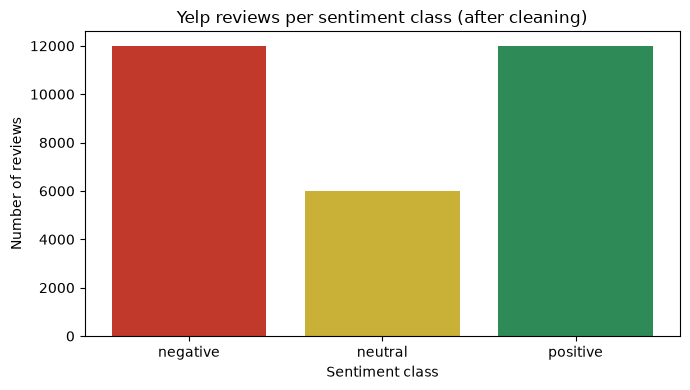

In [7]:
order = ["negative", "neutral", "positive"]
raw_dist = to_sentiment(raw["rating"])
raw_counts = pd.Series(raw_dist).value_counts().reindex(order)
clean_counts = df["sentiment"].value_counts().reindex(order)

print(pd.DataFrame({"before cleaning": raw_counts, "after cleaning": clean_counts}).to_string())

plt.figure(figsize=(7, 4))
plt.bar(order, clean_counts.values, color=["#C0392B", "#C9B037", "#2E8B57"])
plt.title("Yelp reviews per sentiment class (after cleaning)")
plt.xlabel("Sentiment class")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.savefig(OUT_DIR / "class_distribution.png", dpi=120)
plt.show()

### 6. Review Length Before and After Cleaning

Length summary
       char_count  words_before  words_after
count     29998.0       29998.0      29998.0
mean        735.9         134.7         69.0
std         661.8         121.0         61.1
min           2.0           1.0          1.0
25%         289.0          53.0         28.0
50%         541.0         100.0         51.0
75%         964.0         177.0         90.0
max        5057.0         991.0        521.0

Average cleaned word count by class
sentiment
negative    77.1
neutral     72.1
positive    59.4


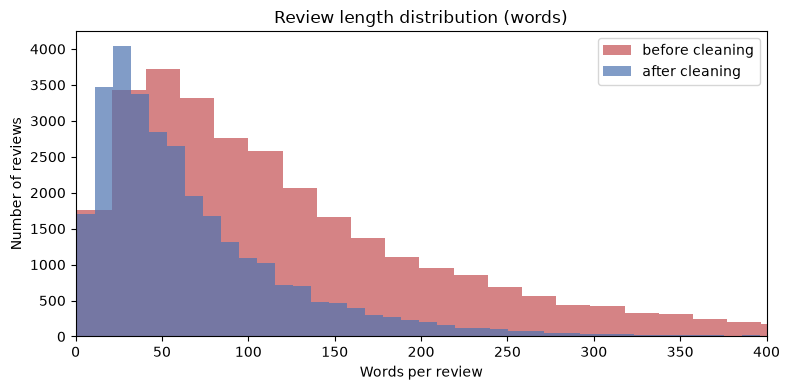

In [8]:
df["char_count"] = df["review"].astype(str).str.len()
df["words_before"] = df["review"].astype(str).str.split().str.len()
df["words_after"] = df["clean_text"].str.split().str.len()

print("Length summary")
print(df[["char_count", "words_before", "words_after"]].describe().round(1).to_string())

print("\nAverage cleaned word count by class")
print(df.groupby("sentiment")["words_after"].mean().round(1).reindex(order).to_string())

plt.figure(figsize=(8, 4))
plt.hist(df["words_before"], bins=50, color="#C44E52", alpha=0.7, label="before cleaning")
plt.hist(df["words_after"], bins=50, color="#4C72B0", alpha=0.7, label="after cleaning")
plt.title("Review length distribution (words)")
plt.xlabel("Words per review")
plt.ylabel("Number of reviews")
plt.xlim(0, 400)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "length_distribution.png", dpi=120)
plt.show()

### 7. Feature Space

In [9]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X = vectorizer.fit_transform(df["clean_text"])
features = np.array(vectorizer.get_feature_names_out())

vocabulary = set()
for doc in df["clean_text"]:
    vocabulary.update(doc.split())

density = X.nnz / (X.shape[0] * X.shape[1])

print("Distinct words after cleaning :", len(vocabulary))
print("TF-IDF features kept          :", X.shape[1])
print("Matrix shape                  :", X.shape)
print(f"Non-zero cells                : {X.nnz:,} ({density:.2%} of the matrix)")
print(f"Sparsity                      : {1 - density:.2%} zeros")

Distinct words after cleaning : 42443
TF-IDF features kept          : 10000
Matrix shape                  : (29998, 10000)
Non-zero cells                : 1,907,686 (0.64% of the matrix)
Sparsity                      : 99.36% zeros


### 8. Class-Separating Terms

In [10]:
def chi2_top_words_per_class(X, features, labels, top_n=12):
    result = {}
    for label in sorted(labels.unique()):
        mask = (labels == label).values
        scores, _ = chi2(X, mask.astype(int))

        # chi2 is high for a word that is unusually common in the class AND for one that
        # is unusually absent, so keep only the words that are heavier inside the class.
        mean_in = np.asarray(X[mask].mean(axis=0)).ravel()
        mean_out = np.asarray(X[~mask].mean(axis=0)).ravel()
        characteristic = mean_in > mean_out

        order = np.argsort(scores)[::-1]
        picks = [i for i in order if characteristic[i]][:top_n]
        result[label] = [(features[i], float(scores[i])) for i in picks]
    return result


chi_words = chi2_top_words_per_class(X, features, df["sentiment"])

for label in sorted(chi_words):
    print(f"{label}: " + ", ".join(word for word, _ in chi_words[label]))

negative: horrible, rude, bad, tell, terrible, no, manager, not even, customer, poor, ask, minute
neutral: decent, three star, not bad, ok, pretty, pretty good, okay, average, good, bit, hit miss, though
positive: great, love, delicious, amaze, awesome, favorite, highly recommend, excellent, best, perfect, amazing, friendly


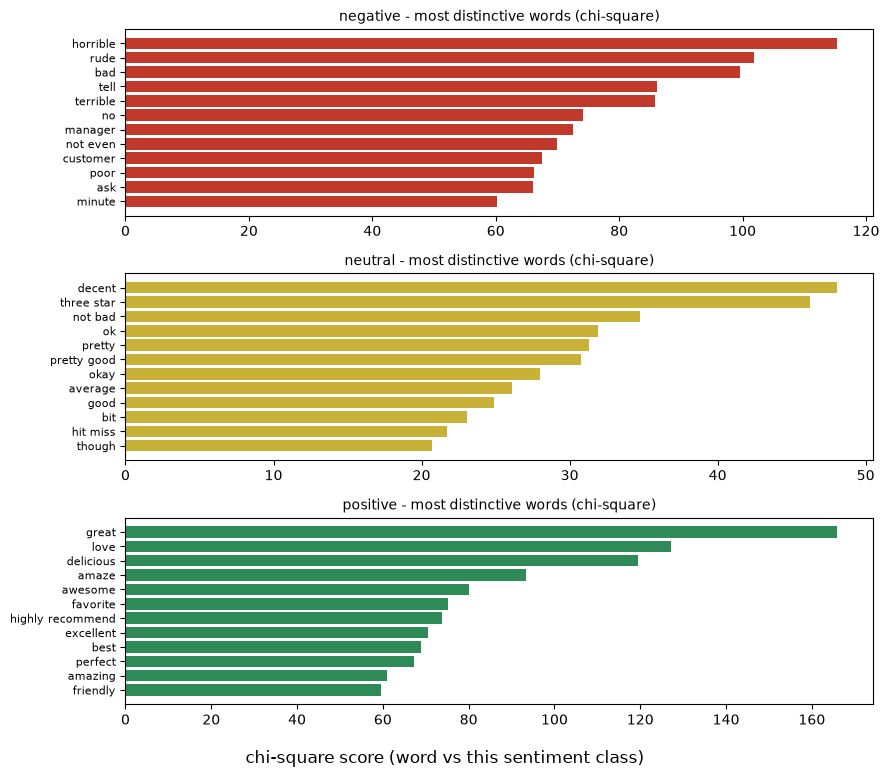

In [11]:
spectrum = ["#C0392B", "#C9B037", "#2E8B57"]
fig, axes = plt.subplots(len(chi_words), 1, figsize=(9, 2.6 * len(chi_words)))

for ax, label, color in zip(axes, sorted(chi_words), spectrum):
    pairs = chi_words[label][::-1]   # largest ends up on top
    ax.barh([word for word, _ in pairs], [score for _, score in pairs], color=color)
    ax.set_title(f"{label} - most distinctive words (chi-square)", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)

fig.supxlabel("chi-square score (word vs this sentiment class)")
fig.tight_layout()
fig.savefig(OUT_DIR / "chi2_top_words_per_class.png", dpi=120)
plt.show()

### 9. Suggested Predictive Models

The EDA points to three things that decide which models are worth trying: the TF-IDF matrix
is 29,998 x 10,000 and 99.36% zeros, the classes are imbalanced 2:1:2, and the vocabulary
separates cleanly at the poles but not in the middle.

Four models are proposed, one per group member, chosen to cover different learning
strategies rather than four versions of the same idea.

| Model | Member | Why it suits this data |
|---|---|---|
| Logistic Regression | Chung Ying Xin | Linear model suited to sparse features, and its coefficients read back as per-class word weights. |
| Linear SVM | Christabel Joyce Joseph | Maximum-margin boundary depends on the reviews nearest the split, which is where neutral sits. |
| Multinomial Naive Bayes | Genemor Muyangana | The only generative model here. Its assumption that terms are independent is testable against neutral's overlapping bigrams such as `not bad`. |
| Random Forest | Joshua Ong | The only non-linear model, capturing term interactions with no distributional assumption, so it tests whether a linear boundary is enough. |

Because neutral has half the reviews of each polar class, accuracy alone would flatter any
model that simply avoids predicting neutral. Macro F1 is therefore used as the headline
metric in Q3 and Q4, since it weights all three classes equally. Which model performs best
is decided in Q4.

### 10. Save the Cleaned Dataset

In [12]:
out = df[["review", "clean_text", "rating", "sentiment"]].copy()
out.to_csv(CLEAN_FILE, index=False)

print("Saved  :", CLEAN_FILE)
print("Columns:", list(out.columns))
print("Rows   :", len(out))

Saved  : ..\data\yelp_clean.csv
Columns: ['review', 'clean_text', 'rating', 'sentiment']
Rows   : 29998
